# 1D Tight Binding from Inspectable Real-Space Physics

In this notebook, we build the tight-binding picture from an inspectable real-space Hamiltonian.

The usual tight-binding model starts from matrix elements such as

$$
H_{nm}
=
E_0\delta_{nm}
-
t
\left(
\delta_{n,m+1}
+
\delta_{n,m-1}
\right)
$$

This is useful, but it hides the physics. The parameter $t$ is inserted directly, so the student does not see where the hopping comes from.

Here we do one level better.

We start from a real-space Hamiltonian,

$$
\hat H
=
-\frac{\hbar^2}{2m}
\frac{d^2}{dx^2}
+
V(x)
$$

Then we construct a chain of attractive atomic wells,

$$
V(x)
=
\sum_{n=0}^{N-1}
v(x-x_n)
$$

where

$$
v(x-x_n)
=
-V_0
\exp\left[
-\frac{(x-x_n)^2}{2\sigma^2}
\right]
$$

The workflow is:

1. Build a real-space grid.
2. Build a finite-difference Hamiltonian.
3. Solve the single-well problem.
4. Shift the single-well bound state to construct localized orbitals.
5. Build multi-well potentials.
6. Compute orbital overlaps.
7. Compute Hamiltonian matrix elements.
8. Solve the generalized eigenvalue problem

$$
H\mathbf{c}
=
E S\mathbf{c}
$$

This gives an inspectable route from real-space physics to tight-binding matrix mechanics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

## 1. Real-Space Grid

We represent the continuous coordinate $x$ by a uniform grid,

$$
x_i
=
x_{\min}
+
i\Delta x
$$

where

$$
i=0,1,\ldots,N_x-1
$$

The grid spacing is

$$
\Delta x
=
\frac{x_{\max}-x_{\min}}{N_x-1}
$$

A wavefunction is represented by a vector,

$$
\boldsymbol{\psi}
=
\begin{bmatrix}
\psi(x_0) & \psi(x_1) & \cdots & \psi(x_{N_x-1})
\end{bmatrix}^{\mathsf T}
$$

Numerical inner products approximate continuum integrals:

$$
\langle \psi|\phi\rangle
=
\int \psi^*(x)\phi(x)\,dx
\approx
\sum_i \psi_i^*\phi_i\Delta x
$$

In [4]:
# ----------------------------
# Real-space grid
# ----------------------------

x_min = -12.0
x_max = 12.0
Nx = 1600

x = np.linspace(x_min, x_max, Nx)
dx = x[1] - x[0]

print(f"dx = {dx:.5f}")

dx = 0.01501


## 2. Finite-Difference Kinetic Energy Operator

We use dimensionless units,

$$
\hbar = 1
$$

and

$$
m = 1
$$

so the kinetic energy operator is

$$
\hat K
=
-\frac{1}{2}
\frac{d^2}{dx^2}
$$

The second derivative is approximated by the centered finite difference,

$$
\frac{d^2\psi}{dx^2}(x_i)
\approx
\frac{
\psi_{i+1}
-
2\psi_i
+
\psi_{i-1}
}{\Delta x^2}
$$

Therefore the matrix representation of the kinetic energy operator is

$$
K
=
-\frac{1}{2}D_2
$$

where $D_2$ is the finite-difference second-derivative matrix.

We use Dirichlet boundary conditions at the edges of the computational box. This means the wavefunction is forced to vanish at the boundaries.

In [5]:
def second_derivative_matrix(Nx: int, dx: float) -> np.ndarray:
    """
    Build the centered finite-difference second derivative matrix.

    Dirichlet boundary behavior is implicit because the finite box
    does not connect the endpoints.
    """
    D2 = np.zeros((Nx, Nx), dtype=float)

    main = -2.0 / dx**2
    off = 1.0 / dx**2

    for i in range(Nx):
        D2[i, i] = main

    for i in range(Nx - 1):
        D2[i, i + 1] = off
        D2[i + 1, i] = off

    return D2


D2 = second_derivative_matrix(Nx, dx)
K = -0.5 * D2

## 3. A Single Atomic Well

We model one atom by an attractive Gaussian well,

$$
v(x-x_0)
=
-V_0
\exp\left[
-\frac{(x-x_0)^2}{2\sigma^2}
\right]
$$

This is not a literal Coulomb potential. It is a smooth attractive potential that supports localized bound states and is numerically stable.

The single-well Hamiltonian is

$$
H_{\mathrm{atom}}
=
K
+
V_{\mathrm{atom}}
$$

where $V_{\mathrm{atom}}$ is a diagonal matrix whose entries are $v(x_i-x_0)$.

In [6]:
def gaussian_well(
    x: np.ndarray,
    center: float,
    V0: float,
    sigma: float,
) -> np.ndarray:
    """
    Attractive Gaussian well centered at `center`.

        v(x) = -V0 exp[-(x-center)^2/(2 sigma^2)]
    """
    return -V0 * np.exp(-((x - center) ** 2) / (2.0 * sigma**2))


def diagonal_potential(V: np.ndarray) -> np.ndarray:
    """
    Convert a potential vector V(x_i) into a diagonal matrix.
    """
    return np.diag(V)

In [7]:
# ----------------------------
# Single atomic well parameters
# ----------------------------

V0 = 8.0
sigma = 0.45
center = 0.0

V_atom = gaussian_well(x, center=center, V0=V0, sigma=sigma)
H_atom = K + diagonal_potential(V_atom)

E_atom, psi_atom = eigh(H_atom)

print("Lowest single-well eigenvalues:")
print(E_atom[:6])

Lowest single-well eigenvalues:
[-5.32301686 -1.13789237  0.03202424  0.04107882  0.12940221  0.16352287]


## 4. Inspecting the Bound State

The lowest eigenstate of the single well is a localized atomic orbital.

We will use this state as the prototype orbital,

$$
\varphi(x)
$$

Then an orbital centered at site $x_n$ will be approximated by a shifted copy,

$$
\varphi_n(x)
=
\varphi(x-x_n)
$$

Before doing that, we normalize the eigenvector using the continuum inner product,

$$
\int |\varphi(x)|^2\,dx = 1
$$

In [8]:
def normalize_continuum(psi: np.ndarray, dx: float) -> np.ndarray:
    """
    Normalize a wavefunction using the continuum inner product.
    """
    norm = np.sqrt(np.sum(np.abs(psi) ** 2) * dx)
    return psi / norm


phi_atom = normalize_continuum(psi_atom[:, 0], dx)

# Choose sign convention for plotting
if phi_atom[np.argmax(np.abs(phi_atom))] < 0:
    phi_atom = -phi_atom

print("Continuum norm:")
print(np.sum(np.abs(phi_atom) ** 2) * dx)

Continuum norm:
1.0


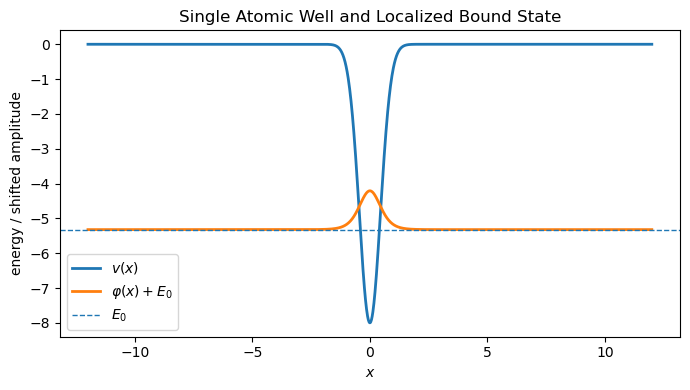

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x, V_atom, linewidth=2, label=r"$v(x)$")
ax.plot(x, phi_atom + E_atom[0], linewidth=2, label=r"$\varphi(x)+E_0$")

ax.axhline(E_atom[0], linestyle="--", linewidth=1, label=r"$E_0$")

ax.set_xlabel("$x$")
ax.set_ylabel("energy / shifted amplitude")
ax.set_title("Single Atomic Well and Localized Bound State")

ax.legend()

plt.tight_layout()
plt.show()

## 5. Two Wells and Orbital Overlap

Now place two identical wells a distance $r$ apart.

The two atomic centers are

$$
x_L=-\frac{r}{2}
$$

and

$$
x_R=\frac{r}{2}
$$

The two localized orbitals are

$$
\varphi_L(x)
=
\varphi(x+r/2)
$$

and

$$
\varphi_R(x)
=
\varphi(x-r/2)
$$

Their overlap is

$$
S_{LR}(r)
=
\langle \varphi_L|\varphi_R\rangle
=
\int \varphi_L^*(x)\varphi_R(x)\,dx
$$

In a real-space calculation, this becomes

$$
S_{LR}(r)
\approx
\sum_i
\varphi_L^*(x_i)\varphi_R(x_i)\Delta x
$$

This is the first inspectable quantity: students can see the localized orbitals and compute their overlap.

In [10]:
def shifted_orbital(
    x: np.ndarray,
    phi_reference: np.ndarray,
    center: float,
) -> np.ndarray:
    """
    Shift a reference orbital centered at x=0 to a new center.

    Uses interpolation on the fixed grid.
    Values outside the grid are filled with zero.
    """
    return np.interp(
        x,
        x + center,
        phi_reference,
        left=0.0,
        right=0.0,
    )


def inner_product(psi: np.ndarray, phi: np.ndarray, dx: float) -> float:
    """
    Continuum inner product for real wavefunctions.
    """
    return np.sum(np.conjugate(psi) * phi) * dx

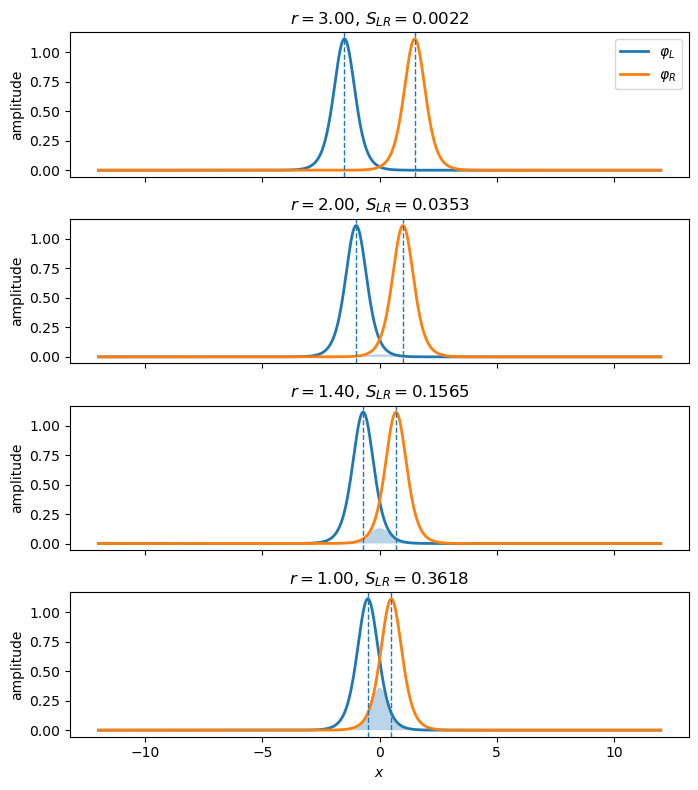

In [11]:
r_demo_values = [3.0, 2.0, 1.4, 1.0]

fig, axes = plt.subplots(
    nrows=len(r_demo_values),
    ncols=1,
    figsize=(7, 8),
    sharex=True,
)

for ax, r in zip(axes, r_demo_values):
    xL = -r / 2.0
    xR = r / 2.0

    phi_L = shifted_orbital(x, phi_atom, center=xL)
    phi_R = shifted_orbital(x, phi_atom, center=xR)

    phi_L = normalize_continuum(phi_L, dx)
    phi_R = normalize_continuum(phi_R, dx)

    S_LR = inner_product(phi_L, phi_R, dx)

    ax.plot(x, phi_L, linewidth=2, label=r"$\varphi_L$")
    ax.plot(x, phi_R, linewidth=2, label=r"$\varphi_R$")
    ax.fill_between(x, phi_L * phi_R, alpha=0.3)

    ax.axvline(xL, linestyle="--", linewidth=1)
    ax.axvline(xR, linestyle="--", linewidth=1)

    ax.set_ylabel("amplitude")
    ax.set_title(rf"$r={r:.2f}$, $S_{{LR}}={S_LR:.4f}$")

axes[-1].set_xlabel("$x$")
axes[0].legend()

plt.tight_layout()
plt.show()

## 6. Overlap as a Function of Distance

We now compute

$$
S_{LR}(r)
$$

for many interatomic distances.

This makes the word “overlap” quantitative.

As the atoms move apart,

$$
S_{LR}(r)\to 0
$$

As the atoms move closer,

$$
S_{LR}(r)
$$

increases.

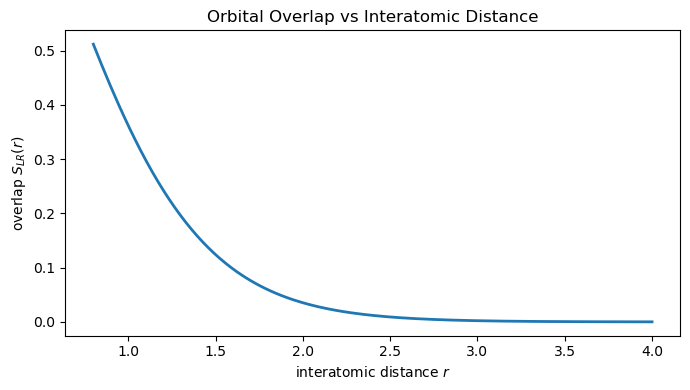

In [12]:
r_values = np.linspace(0.8, 4.0, 200)

S_values = []

for r in r_values:
    phi_L = shifted_orbital(x, phi_atom, center=-r / 2.0)
    phi_R = shifted_orbital(x, phi_atom, center= r / 2.0)

    phi_L = normalize_continuum(phi_L, dx)
    phi_R = normalize_continuum(phi_R, dx)

    S_LR = inner_product(phi_L, phi_R, dx)
    S_values.append(S_LR)

S_values = np.array(S_values)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(r_values, S_values, linewidth=2)

ax.set_xlabel("interatomic distance $r$")
ax.set_ylabel(r"overlap $S_{LR}(r)$")
ax.set_title("Orbital Overlap vs Interatomic Distance")

plt.tight_layout()
plt.show()

## 7. Two-Well Continuum Hamiltonian

The two-well potential is

$$
V_2(x;r)
=
v(x+r/2)
+
v(x-r/2)
$$

The corresponding real-space Hamiltonian is

$$
H_x(r)
=
K
+
V_2(x;r)
$$

where $V_2$ is represented as a diagonal matrix.

Diagonalizing $H_x(r)$ gives the actual continuum eigenstates of the two-well system.

For large separation, the two lowest states are nearly degenerate.

For smaller separation, the degeneracy is lifted into a bonding state and an antibonding state.

In [13]:
def two_well_potential(
    x: np.ndarray,
    r: float,
    V0: float,
    sigma: float,
) -> np.ndarray:
    """
    Two identical Gaussian wells separated by distance r.
    """
    return (
        gaussian_well(x, center=-r / 2.0, V0=V0, sigma=sigma)
        +
        gaussian_well(x, center= r / 2.0, V0=V0, sigma=sigma)
    )


def continuum_hamiltonian(K: np.ndarray, V: np.ndarray) -> np.ndarray:
    """
    Real-space finite-difference Hamiltonian H = K + V.
    """
    return K + diagonal_potential(V)

In [14]:
r_demo = 1.6

V_two = two_well_potential(x, r=r_demo, V0=V0, sigma=sigma)
H_two = continuum_hamiltonian(K, V_two)

E_two, psi_two = eigh(H_two)

psi0 = normalize_continuum(psi_two[:, 0], dx)
psi1 = normalize_continuum(psi_two[:, 1], dx)

# Sign convention for plotting
if psi0[np.argmax(np.abs(psi0))] < 0:
    psi0 = -psi0

if psi1[np.argmax(np.abs(psi1))] < 0:
    psi1 = -psi1

print("Lowest two-well eigenvalues:")
print(E_two[:6])

print("Splitting between two lowest states:")
print(E_two[1] - E_two[0])

Lowest two-well eigenvalues:
[-5.70780352 -5.16835434 -1.83851315 -0.38282335  0.04220573  0.05178254]
Splitting between two lowest states:
0.5394491830968455


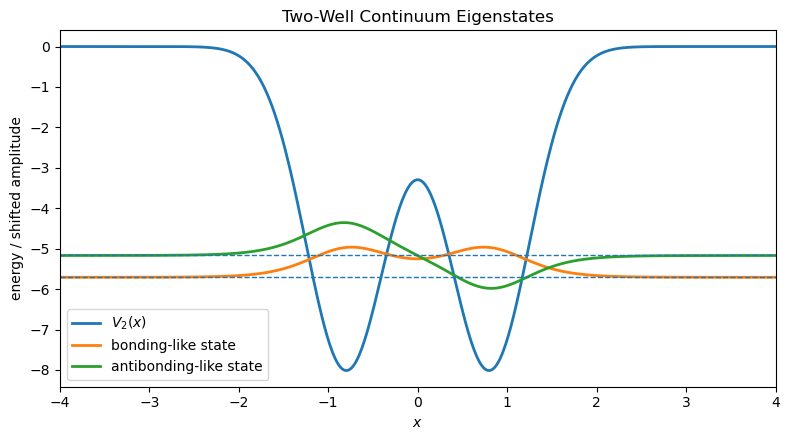

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))

scale = 1.0

ax.plot(x, V_two, linewidth=2, label=r"$V_2(x)$")

ax.plot(x, scale * psi0 + E_two[0], linewidth=2, label="bonding-like state")
ax.plot(x, scale * psi1 + E_two[1], linewidth=2, label="antibonding-like state")

ax.axhline(E_two[0], linestyle="--", linewidth=1)
ax.axhline(E_two[1], linestyle="--", linewidth=1)

ax.set_xlim(-4, 4)

ax.set_xlabel("$x$")
ax.set_ylabel("energy / shifted amplitude")
ax.set_title("Two-Well Continuum Eigenstates")

ax.legend()

plt.tight_layout()
plt.show()